In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
llm_gpt = ChatOpenAI(model='gpt-4o', temperature=0)

/Users/shudhanshu/Desktop/Study Projects/GenAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [6]:
import requests
from langchain_core.tools import tool

In [7]:
@tool
def get_weather(query:str)->list:
    """Search weatherapi to get the current weather."""
    base_url = "https://api.openweathermap.org/data/2.5/weather"
    complete_url = f"{base_url}?q={query}&APPID={os.environ.get('WEATHER_API_KEY')}"

    response = requests.get(complete_url)
    data = response.json()

    print(complete_url)
    print(data)
    if data.get('name'):
        return data
    else:
        return "weather data not found"

In [8]:
tools = [get_weather]

In [11]:
llm_with_tools=llm_gpt.bind_tools(tools=tools)

In [12]:
llm_with_tools.invoke("what is ai in 1 line")

AIMessage(content='AI, or Artificial Intelligence, is the simulation of human intelligence processes by machines, especially computer systems, to perform tasks that typically require human intelligence.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 53, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64cfb65ad0', 'id': 'chatcmpl-DYS3uSL1BBcncY9VqC59F3xeBzb1j', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc39d-cf81-7e42-9917-43dfe1209528-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 53, 'output_tokens': 30, 'total_tokens': 83, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_

In [13]:
llm_with_tools.invoke("what is current weather in varanasi")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 54, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64cfb65ad0', 'id': 'chatcmpl-DYS4PemdZ0r0gFg0QWRdHhsY2r1Zq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dc39e-490b-7be3-a720-9f04b7fa0ed5-0', tool_calls=[{'name': 'get_weather', 'args': {'query': 'Varanasi'}, 'id': 'call_KnMwClRzub9s1XL6dzCfWFpL', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 54, 'output_tokens': 16, 'total_tokens': 70, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [14]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [25]:
# Augument LLM with tools node function

def tool_calling_llm(state:State)->State:
    current_state = state['messages']
    return {"messages":[llm_with_tools.invoke(current_state)]}

In [26]:
# Build the graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "tool_calling_llm")


# conditional_edge
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    ["tools", END]
)

builder.add_edge("tools", END)
graph = builder.compile()

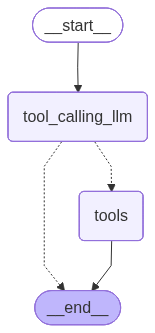

In [27]:
graph

In [28]:
user_input = "Explain AI in 2 bullets"
for event in graph.stream({"messages":user_input},stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Explain AI in 2 bullets
================================== Ai Message ==================================

- **Machine Learning and Algorithms**: AI involves the use of machine learning algorithms and models that enable computers to learn from data, identify patterns, and make decisions with minimal human intervention. These algorithms can be trained to perform specific tasks by analyzing large datasets and improving their performance over time.

- **Automation and Intelligent Systems**: AI encompasses the development of intelligent systems that can automate complex tasks, simulate human-like reasoning, and interact with the environment. This includes applications like natural language processing, computer vision, robotics, and autonomous systems that can perform tasks ranging from simple data analysis to driving vehicles.


In [29]:
user_input = "what is current weather in varanasi"
for event in graph.stream({"messages":user_input},stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

what is current weather in varanasi
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_jPkZZ7Xl4YwFGXbSpjdHFaJE)
 Call ID: call_jPkZZ7Xl4YwFGXbSpjdHFaJE
  Args:
    query: Varanasi
https://api.openweathermap.org/data/2.5/weather?q=Varanasi&APPID=8ce32efc60500f625bb6c5983ce35bee
{'coord': {'lon': 83, 'lat': 25.3333}, 'weather': [{'id': 721, 'main': 'Haze', 'description': 'haze', 'icon': '50d'}], 'base': 'stations', 'main': {'temp': 315.2, 'feels_like': 313.04, 'temp_min': 315.2, 'temp_max': 315.2, 'pressure': 1003, 'humidity': 13, 'sea_level': 1003, 'grnd_level': 995}, 'visibility': 4500, 'wind': {'speed': 2.58, 'deg': 345, 'gust': 3.36}, 'clouds': {'all': 0}, 'dt': 1777104002, 'sys': {'type': 1, 'id': 9138, 'country': 'IN', 'sunrise': 1777075007, 'sunset': 1777121697}, 'timezone': 19800, 'id': 1253405, 'name': 'Varanasi', 'cod': 200}
==========